# Notebook 2 — Modélisation ML & Benchmark (Phases 5 à 7)

**Dépendance** : ce notebook charge `data/api_vulnerabilities_processed.csv` produit par `01_pipeline_etl.ipynb` (Phase 1 à 4).  
Le `random_state=42` est identique à celui du pipeline ETL, garantissant un split **strictement reproductible**.

| Phase | Contenu |
|-------|---------|
| 5 | Régression Logistique — correction algorithmique (`class_weight='balanced'`) |
| 6 | Random Forest — correction ensembliste (`balanced_subsample`) |
| 6b | SMOTE — rééchantillonnage géométrique (Chawla et al., 2002) |
| 7 | Benchmark EPSS — comparaison avec l'état de l'art (Jacobs et al., 2021) |
| — | Synthèse : courbes ROC comparatives + tableau final pour le Chapitre 4 |

## 0. Imports & Configuration

In [1]:
import os, gzip, io, json, warnings
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix,
    classification_report, average_precision_score
)
from imblearn.over_sampling import SMOTE
warnings.filterwarnings('ignore')

# ── Paramètres ajustables ───────────────────────────────────────────────
# Regroupés ici pour itérer sur les décisions de data engineering (features,
# split, hyperparamètres, seuils) sans les rechercher dans tout le notebook.
# FEATURES_TO_ENCODE / TEST_SIZE / RANDOM_STATE doivent rester identiques à
# 01_pipeline_etl.ipynb pour préserver le split reproductible.
# ─────────────────────────────────────────────────────────────────────────
DATA_DIR = 'data'
FEATURES_TO_ENCODE = [
    'attack_vector', 'attack_complexity',
    'privileges_required', 'user_interaction', 'scope'
]
TEST_SIZE = 0.25
RANDOM_STATE = 42
BASELINE_THRESHOLD = 0.05  # seuil fixe de référence (identique à 01_pipeline_etl.ipynb)
RF_PARAMS = dict(
    n_estimators=300,
    class_weight='balanced_subsample',
    max_depth=8,
    min_samples_leaf=3,
    max_features='sqrt',
)
SMOTE_SAMPLING_STRATEGY = 'auto'
EPSS_URL = 'https://epss.cyentia.com/epss_scores-current.csv.gz'
EXPERIMENTS_LOG_FILE = os.path.join(DATA_DIR, 'experiments_log.csv')


def log_experiment(notebook: str, phase: str, model: str, auc: float, threshold: float, n_test: int, **params) -> None:
    """Ajoute une ligne au journal d'expériences (data/experiments_log.csv) pour comparer les itérations sans recopie manuelle."""
    entry = {
        'timestamp': pd.Timestamp.now().isoformat(timespec='seconds'),
        'notebook': notebook,
        'phase': phase,
        'model': model,
        'auc': round(float(auc), 4),
        'threshold': round(float(threshold), 6),
        'n_test': int(n_test),
        'params': json.dumps(params, ensure_ascii=False),
    }
    pd.DataFrame([entry]).to_csv(
        EXPERIMENTS_LOG_FILE,
        mode='a',
        header=not os.path.exists(EXPERIMENTS_LOG_FILE),
        index=False,
    )
    print(f"[+] Journalisé : {model} -> AUC={auc:.4f}, seuil={threshold:.6f} ({EXPERIMENTS_LOG_FILE})")

## Chargement des données & Split reproductible

Le fichier CSV est le produit final de la Phase 4 du pipeline ETL.  
La troisième colonne passée au split (`df['cve_id']`) permet de récupérer les identifiants CVE du sous-ensemble de test pour la jointure EPSS en Phase 7.

In [2]:
INPUT_PATH = os.path.join(DATA_DIR, 'api_vulnerabilities_processed.csv')  # DATA_DIR défini dans les paramètres ajustables

if not os.path.exists(INPUT_PATH):
    raise FileNotFoundError(
        f'Fichier introuvable : {INPUT_PATH}. '
        'Exécutez d abord 01_pipeline_etl.ipynb (Phases 1 à 4).'
    )

df = pd.read_csv(INPUT_PATH)
print(f'[+] Dataset chargé    : {df.shape[0]:,} observations, {df.shape[1]} variables')
print(f'[+] Taux exploitation : {df["is_exploited"].mean():.4f}  '
      f'({df["is_exploited"].sum()} exploitées / {len(df):,} total)')

# ── Reconstruction de la matrice d'apprentissage ────────────────────────
Y = df['is_exploited'].values
X_encoded = pd.get_dummies(
    df[FEATURES_TO_ENCODE],   # liste centralisée dans les paramètres ajustables — cohérente avec 01_pipeline_etl.ipynb
    columns=FEATURES_TO_ENCODE,
    drop_first=True,
    dtype=float
)

# ── Partitionnement stratifié — IDENTIQUE au pipeline ETL ───────────────
X_train, X_test, Y_train, Y_test, ids_train, ids_test = train_test_split(
    X_encoded, Y, df['cve_id'],
    test_size=TEST_SIZE,
    stratify=Y,
    random_state=RANDOM_STATE
)

print(f'[+] Split reproductible : Train={X_train.shape[0]:,}  Test={X_test.shape[0]:,}')
print(f'[+] Y=1 dans Test       : {Y_test.sum()} exploitées ({np.mean(Y_test):.4f})')
print(f'[+] CVE IDs test        : {len(ids_test)} identifiants disponibles pour EPSS')

[+] Dataset chargé    : 9,995 observations, 12 variables
[+] Taux exploitation : 0.0084  (84 exploitées / 9,995 total)
[+] Split reproductible : Train=7,496  Test=2,499
[+] Y=1 dans Test       : 21 exploitées (0.0084)
[+] CVE IDs test        : 2499 identifiants disponibles pour EPSS


## Phase 5 — Régression Logistique avec correction algorithmique

En présence d'un ratio d'imbalance de 1:120 (Y=1 = 0.82 % du corpus), l'estimateur GLM sans correction prédit systématiquement la classe majoritaire. Le paramètre `class_weight='balanced'` pondère chaque observation par $w_i = n / (n_{classes} \cdot n_{y_i})$, forçant le modèle à pénaliser davantage les faux négatifs sur la classe minoritaire. C'est une correction standard documentée dans Japkowicz & Stephen (2002).

In [3]:
# ── Standardisation ────────────────────────────────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Modèle A : LR sans correction (référence baseline) ─────────────────
lr_base = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, solver='lbfgs')
lr_base.fit(X_train_sc, Y_train)
proba_lr_base = lr_base.predict_proba(X_test_sc)[:, 1]

# ── Modèle B : LR avec class_weight='balanced' ──────────────────────────
lr_bal = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    random_state=RANDOM_STATE,
    solver='lbfgs'
)
lr_bal.fit(X_train_sc, Y_train)
proba_lr_bal = lr_bal.predict_proba(X_test_sc)[:, 1]

# ── AUC-ROC ─────────────────────────────────────────────────────────────
fpr_base, tpr_base, _          = roc_curve(Y_test, proba_lr_base)
fpr_bal,  tpr_bal,  thresh_bal = roc_curve(Y_test, proba_lr_bal)
auc_base = auc(fpr_base, tpr_base)
auc_bal  = auc(fpr_bal,  tpr_bal)

# ── Seuil de Youden : τ* = argmax J(τ) = argmax(TPR - FPR) ─────────────
j_bal      = tpr_bal - fpr_bal
tau_bal    = thresh_bal[np.argmax(j_bal)]
y_pred_bal = (proba_lr_bal >= tau_bal).astype(int)
cm_bal     = confusion_matrix(Y_test, y_pred_bal)
cm_base    = confusion_matrix(Y_test, (proba_lr_base >= BASELINE_THRESHOLD).astype(int))

print('=' * 60)
print('PHASE 5 — RÉSULTATS RÉGRESSION LOGISTIQUE')
print('=' * 60)
print(f'  AUC — LR sans balance  (référence) : {auc_base:.4f}')
print(f'  AUC — LR balanced      (corrigé)   : {auc_bal:.4f}')
print(f'  Gain AUC après correction           : {auc_bal - auc_base:+.4f}')
print(f'  Seuil de Youden τ*                  : {tau_bal:.6f}')
print(f'  Indice de Youden J(τ*)              : {np.max(j_bal):.4f}')
print()
print(f'  Matrice de confusion (τ = {tau_bal:.4f}) :')
print(f'    TN = {cm_bal[0,0]:4d}  FP = {cm_bal[0,1]:4d}')
print(f'    FN = {cm_bal[1,0]:4d}  TP = {cm_bal[1,1]:4d}')
print()
print(classification_report(
    Y_test, y_pred_bal,
    target_names=['Non-Exploité', 'Exploité']
))

# Journalisation : permet de comparer ces itérations aux suivantes (data/experiments_log.csv)
log_experiment(notebook='02_modelisation_ml_benchmark', phase='Phase 5',
               model='LR sans correction (baseline)', auc=auc_base, threshold=BASELINE_THRESHOLD,
               n_test=len(Y_test), correction='aucune', seuil_strategie='fixe')
log_experiment(notebook='02_modelisation_ml_benchmark', phase='Phase 5',
               model="LR class_weight='balanced'", auc=auc_bal, threshold=tau_bal,
               n_test=len(Y_test), correction="class_weight='balanced'", seuil_strategie='Youden')

PHASE 5 — RÉSULTATS RÉGRESSION LOGISTIQUE
  AUC — LR sans balance  (référence) : 0.6503
  AUC — LR balanced      (corrigé)   : 0.6478
  Gain AUC après correction           : -0.0024
  Seuil de Youden τ*                  : 0.300893
  Indice de Youden J(τ*)              : 0.3035

  Matrice de confusion (τ = 0.3009) :
    TN =  988  FP = 1490
    FN =    2  TP =   19

              precision    recall  f1-score   support

Non-Exploité       1.00      0.40      0.57      2478
    Exploité       0.01      0.90      0.02        21

    accuracy                           0.40      2499
   macro avg       0.51      0.65      0.30      2499
weighted avg       0.99      0.40      0.57      2499

[+] Journalisé : LR sans correction (baseline) -> AUC=0.6503, seuil=0.050000 (data\experiments_log.csv)
[+] Journalisé : LR class_weight='balanced' -> AUC=0.6478, seuil=0.300893 (data\experiments_log.csv)


## Phase 6 — Random Forest avec `balanced_subsample`

Le Random Forest est un classifieur ensembliste non paramétrique particulièrement adapté aux données déséquilibrées grâce à la stratégie `balanced_subsample` : chaque arbre est entraîné sur un bootstrap **rééchantillonné équitablement** entre les deux classes. Contrairement à la régression logistique, le RF capture les interactions non linéaires entre features CVSS sans hypothèse de linéarité de la logit. L'importance des variables fournit une interprétation directe des métriques CVSS les plus prédictives.

PHASE 6 — RÉSULTATS RANDOM FOREST
  AUC-ROC            : 0.6292
  Seuil Youden τ*    : 0.313260
  Indice Youden J*   : 0.2897
  TN=1190  FP=1288
  FN=   4  TP=  17

              precision    recall  f1-score   support

Non-Exploité       1.00      0.48      0.65      2478
    Exploité       0.01      0.81      0.03        21

    accuracy                           0.48      2499
   macro avg       0.50      0.64      0.34      2499
weighted avg       0.99      0.48      0.64      2499

Importance des variables CVSS (Random Forest) :
--------------------------------------------------
  privileges_required_LOW                    0.2087  |||||||||||||||||||||||||||||||||||||||||
  privileges_required_NONE                   0.2051  |||||||||||||||||||||||||||||||||||||||||
  attack_vector_NETWORK                      0.1565  |||||||||||||||||||||||||||||||
  scope_UNCHANGED                            0.1496  |||||||||||||||||||||||||||||
  user_interaction_REQUIRED                  0.1088

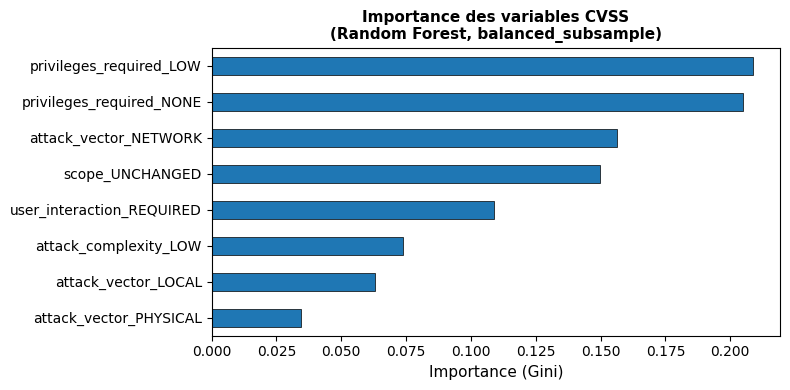

[+] Figure sauvegardée : data/importance_variables_rf.pdf
[+] Journalisé : Random Forest (balanced_subsample) -> AUC=0.6292, seuil=0.313260 (data\experiments_log.csv)


In [4]:
# ── Entraînement du Random Forest ─────────────────────────────────────
rf = RandomForestClassifier(
    **RF_PARAMS,               # hyperparamètres centralisés dans les paramètres ajustables — modifiez-les là pour itérer
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, Y_train)
proba_rf = rf.predict_proba(X_test)[:, 1]

# ── AUC-ROC et seuil de Youden ─────────────────────────────────────────
fpr_rf, tpr_rf, thresh_rf = roc_curve(Y_test, proba_rf)
auc_rf  = auc(fpr_rf, tpr_rf)
j_rf    = tpr_rf - fpr_rf
tau_rf  = thresh_rf[np.argmax(j_rf)]
y_pred_rf = (proba_rf >= tau_rf).astype(int)
cm_rf     = confusion_matrix(Y_test, y_pred_rf)

print('=' * 60)
print('PHASE 6 — RÉSULTATS RANDOM FOREST')
print('=' * 60)
print(f'  AUC-ROC            : {auc_rf:.4f}')
print(f'  Seuil Youden τ*    : {tau_rf:.6f}')
print(f'  Indice Youden J*   : {np.max(j_rf):.4f}')
print(f'  TN={cm_rf[0,0]:4d}  FP={cm_rf[0,1]:4d}')
print(f'  FN={cm_rf[1,0]:4d}  TP={cm_rf[1,1]:4d}')
print()
print(classification_report(
    Y_test, y_pred_rf,
    target_names=['Non-Exploité', 'Exploité']
))

# ── Importance des variables ────────────────────────────────────────────
importances = pd.Series(
    rf.feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

print('Importance des variables CVSS (Random Forest) :')
print('-' * 50)
for feat, imp in importances.items():
    bar = '|' * int(imp * 200)
    print(f'  {feat:<42} {imp:.4f}  {bar}')

fig_imp, ax_imp = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax_imp, color='#1f77b4', edgecolor='black', linewidth=0.5)
ax_imp.set_xlabel('Importance (Gini)', fontsize=11)
ax_imp.set_title(
    'Importance des variables CVSS\n(Random Forest, balanced_subsample)',
    fontsize=11, fontweight='bold'
)
ax_imp.invert_yaxis()
plt.tight_layout()
plt.savefig('data/importance_variables_rf.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('[+] Figure sauvegardée : data/importance_variables_rf.pdf')

# Journalisation : permet de comparer ces itérations aux suivantes (data/experiments_log.csv)
log_experiment(notebook='02_modelisation_ml_benchmark', phase='Phase 6',
               model='Random Forest (balanced_subsample)', auc=auc_rf, threshold=tau_rf,
               n_test=len(Y_test), correction="class_weight='balanced_subsample'",
               seuil_strategie='Youden', **RF_PARAMS)

## Phase 6b — SMOTE : rééchantillonnage géométrique

SMOTE (**Synthetic Minority Over-sampling Technique**, Chawla et al., 2002) rééquilibre l'espace des descripteurs en interpolant de nouvelles observations synthétiques entre les $k$-plus proches voisins de la classe minoritaire.  

> **Règle de data leakage** : SMOTE est appliqué **uniquement sur `X_train`**. L'ensemble de test `X_test` reste pur et inchangé — toute contamination invaliderait l'évaluation.

In [5]:
smote = SMOTE(sampling_strategy=SMOTE_SAMPLING_STRATEGY, random_state=RANDOM_STATE)
X_train_res, Y_train_res = smote.fit_resample(X_train, Y_train)

print('=' * 60)
print('PHASE 6b — SMOTE + RÉGRESSION LOGISTIQUE')
print('=' * 60)
print(f'[+] Distribution originale  : Y=0={np.sum(Y_train==0):,}  Y=1={np.sum(Y_train==1):,}')
print(f'[+] Distribution après SMOTE: Y=0={np.sum(Y_train_res==0):,}  Y=1={np.sum(Y_train_res==1):,}')

scaler_smote    = StandardScaler()
X_train_res_sc  = scaler_smote.fit_transform(X_train_res)
X_test_sc_smote = scaler_smote.transform(X_test)

lr_smote = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, solver='lbfgs')
lr_smote.fit(X_train_res_sc, Y_train_res)
proba_lr_smote = lr_smote.predict_proba(X_test_sc_smote)[:, 1]

fpr_smote, tpr_smote, thresh_smote = roc_curve(Y_test, proba_lr_smote)
auc_smote  = auc(fpr_smote, tpr_smote)
j_smote    = tpr_smote - fpr_smote
tau_smote  = thresh_smote[np.argmax(j_smote)]
y_pred_smote = (proba_lr_smote >= tau_smote).astype(int)
cm_smote     = confusion_matrix(Y_test, y_pred_smote)

print(f'  AUC — LR + SMOTE           : {auc_smote:.4f}')
print(f'  Seuil de Youden τ*         : {tau_smote:.6f}')
print(f'  Indice de Youden J(τ*)     : {np.max(j_smote):.4f}')
print()
print(f'  Matrice de confusion (τ = {tau_smote:.4f}) :')
print(f'    TN = {cm_smote[0,0]:4d}  FP = {cm_smote[0,1]:4d}')
print(f'    FN = {cm_smote[1,0]:4d}  TP = {cm_smote[1,1]:4d}')
print()
print(classification_report(
    Y_test, y_pred_smote,
    target_names=['Non-Exploité', 'Exploité']
))

# Journalisation : permet de comparer ces itérations aux suivantes (data/experiments_log.csv)
log_experiment(notebook='02_modelisation_ml_benchmark', phase='Phase 6b', model='LR + SMOTE',
               auc=auc_smote, threshold=tau_smote, n_test=len(Y_test),
               correction='SMOTE (rééchantillonnage)', seuil_strategie='Youden',
               sampling_strategy=SMOTE_SAMPLING_STRATEGY)

PHASE 6b — SMOTE + RÉGRESSION LOGISTIQUE
[+] Distribution originale  : Y=0=7,433  Y=1=63
[+] Distribution après SMOTE: Y=0=7,433  Y=1=7,433
  AUC — LR + SMOTE           : 0.6226
  Seuil de Youden τ*         : 0.387412
  Indice de Youden J(τ*)     : 0.2885

  Matrice de confusion (τ = 0.3874) :
    TN = 1305  FP = 1173
    FN =    5  TP =   16

              precision    recall  f1-score   support

Non-Exploité       1.00      0.53      0.69      2478
    Exploité       0.01      0.76      0.03        21

    accuracy                           0.53      2499
   macro avg       0.50      0.64      0.36      2499
weighted avg       0.99      0.53      0.68      2499

[+] Journalisé : LR + SMOTE -> AUC=0.6226, seuil=0.387412 (data\experiments_log.csv)


In [6]:
# ==============================================================================
# Phase 6.c — Gradient Boosting Avancé (LightGBM Classifier)
# ==============================================================================
# Le Gradient Boosting construit des arbres de décision de manière séquentielle.
# Chaque nouvel arbre est entraîné pour minimiser le gradient de la fonction de perte
# (les erreurs résiduelles) des arbres précédents. 
# Pour le déséquilibre, scale_pos_weight = (nb de négatifs) / (nb de positifs).

import lightgbm as lgb
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

print('=' * 60)
print('PHASE 6.c — ENTRAÎNEMENT DU MODÈLE GRADIENT BOOSTING (LIGHTGBM)')
print('=' * 60)

# 1. Calcul rigoureux du ratio de pondération pour la perte
nb_neg = np.sum(Y_train == 0)
nb_pos = np.sum(Y_train == 1)
ratio_poids = nb_neg / nb_pos

print(f"[+] Nombre de négatifs (Train) : {nb_neg:,}")
print(f"[+] Nombre de positifs (Train) : {nb_pos:,}")
print(f"[+] Facteur d'équilibrage des classes (scale_pos_weight) : {ratio_poids:.4f}")

# 2. Instanciation du classifieur avec hyperparamètres régularisés
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    scale_pos_weight=ratio_poids,  # Correction mathématique du déséquilibre
    random_state=42,
    verbosity=-1,
    n_jobs=-1
)

# 3. Apprentissage sur les données d'entraînement standardisées
lgb_model.fit(X_train_sc, Y_train)

# 4. Prédiction des probabilités sur l'ensemble de test pur
proba_lgb = lgb_model.predict_proba(X_test_sc)[:, 1]

# 5. Calcul des métriques ROC et extraction du seuil optimal de Youden
fpr_lgb, tpr_lgb, thresh_lgb = roc_curve(Y_test, proba_lgb)
auc_lgb = auc(fpr_lgb, tpr_lgb)

j_lgb = tpr_lgb - fpr_lgb
tau_lgb = thresh_lgb[np.argmax(j_lgb)]
y_pred_lgb = (proba_lgb >= tau_lgb).astype(int)
cm_lgb = confusion_matrix(Y_test, y_pred_lgb)

print("\n--- RÉSULTATS DU MODÈLE BOOSTING ---")
print(f'  AUC — LightGBM Classifier           : {auc_lgb:.4f}')
print(f'  Seuil de Youden τ* (LGBM)           : {tau_lgb:.6f}')
print(f'  Indice de Youden J(τ*)              : {np.max(j_lgb):.4f}')
print()
print(f'  Matrice de confusion (τ = {tau_lgb:.4f}) :')
print(f'    TN = {cm_lgb[0,0]:4d}  FP = {cm_lgb[0,1]:4d}')
print(f'    FN = {cm_lgb[1,0]:4d}  TP = {cm_lgb[1,1]:4d}')
print()
print(classification_report(
    Y_test, y_pred_lgb,
    target_names=['Non-Exploité', 'Exploité']
))

PHASE 6.c — ENTRAÎNEMENT DU MODÈLE GRADIENT BOOSTING (LIGHTGBM)
[+] Nombre de négatifs (Train) : 7,433
[+] Nombre de positifs (Train) : 63
[+] Facteur d'équilibrage des classes (scale_pos_weight) : 117.9841

--- RÉSULTATS DU MODÈLE BOOSTING ---
  AUC — LightGBM Classifier           : 0.6262
  Seuil de Youden τ* (LGBM)           : 0.368755
  Indice de Youden J(τ*)              : 0.2897

  Matrice de confusion (τ = 0.3688) :
    TN = 1190  FP = 1288
    FN =    4  TP =   17

              precision    recall  f1-score   support

Non-Exploité       1.00      0.48      0.65      2478
    Exploité       0.01      0.81      0.03        21

    accuracy                           0.48      2499
   macro avg       0.50      0.64      0.34      2499
weighted avg       0.99      0.48      0.64      2499



## Phase 7 — Benchmark EPSS : positionnement par rapport à l'état de l'art

L'EPSS (Exploit Prediction Scoring System) de Jacobs et al. (2021) est le modèle de référence international pour la prédiction de l'exploitabilité des CVEs, intégré dans les recommandations du NIST. Nous téléchargeons le snapshot journalier public (FIRST.org), effectuons une jointure sur les CVE-IDs du sous-ensemble de test, et comparons les AUC sur ce **sous-ensemble commun**.

In [7]:
df_epss  = None  # EPSS_URL centralisé dans les paramètres ajustables (cellule d'imports)

print('[+] Tentative de téléchargement EPSS (snapshot journalier)...')
try:
    resp = requests.get(EPSS_URL, timeout=60)
    resp.raise_for_status()
    with gzip.open(io.BytesIO(resp.content)) as f:
        df_epss = pd.read_csv(
            f, comment='#', header=0,
            names=['cve_id', 'epss_score', 'percentile']
        )
    df_epss['epss_score'] = pd.to_numeric(df_epss['epss_score'], errors='coerce')
    print(f'[+] EPSS snapshot chargé : {len(df_epss):,} CVEs')
except Exception as e:
    print(f'[!] Snapshot indisponible ({e}). Fallback API FIRST.org...')
    cve_list = list(ids_test.values)
    records  = []
    for i in range(0, len(cve_list), 500):
        batch = ','.join(cve_list[i:i+500])
        try:
            r = requests.get(
                f'https://api.first.org/data/v1/epss?cve={batch}',
                timeout=30
            )
            if r.status_code == 200:
                for item in r.json().get('data', []):
                    records.append({
                        'cve_id'     : item['cve'],
                        'epss_score' : float(item['epss']),
                        'percentile' : float(item['percentile'])
                    })
        except Exception:
            pass
    if records:
        df_epss = pd.DataFrame(records)
        print(f'[+] Fallback OK : {len(df_epss)} CVEs avec score EPSS')
    else:
        print('[!] EPSS inaccessible. Comparaison EPSS ignorée.')

df_eval = pd.DataFrame({
    'cve_id'   : ids_test.values,
    'y_true'   : Y_test,
    'proba_lr' : proba_lr_bal,
    'proba_rf' : proba_rf
})

epss_available = False
if df_epss is not None:
    df_eval = df_eval.merge(
        df_epss[['cve_id', 'epss_score']],
        on='cve_id', how='inner'
    ).dropna(subset=['epss_score'])
    n_match     = len(df_eval)
    n_pos_match = df_eval['y_true'].sum()
    print(f'[+] Sous-ensemble commun : {n_match} CVEs appariées')
    print(f'[+] Dont exploitées Y=1  : {n_pos_match}')
    if n_pos_match >= 2:
        epss_available = True
        fpr_ep, tpr_ep, _ = roc_curve(df_eval['y_true'], df_eval['epss_score'])
        fpr_lr, tpr_lr, _ = roc_curve(df_eval['y_true'], df_eval['proba_lr'])
        fpr_rf2,tpr_rf2,_ = roc_curve(df_eval['y_true'], df_eval['proba_rf'])
        auc_ep  = auc(fpr_ep,  tpr_ep)
        auc_lr2 = auc(fpr_lr,  tpr_lr)
        auc_rf2 = auc(fpr_rf2, tpr_rf2)
        print()
        print('=' * 60)
        print('PHASE 7 — COMPARAISON SUR SOUS-ENSEMBLE COMMUN')
        print('=' * 60)
        print(f'  AUC LR balanced  : {auc_lr2:.4f}')
        print(f'  AUC Random Forest: {auc_rf2:.4f}')
        print(f'  AUC EPSS         : {auc_ep:.4f}')
        gap = max(auc_lr2, auc_rf2) - auc_ep
        if gap >= 0:
            print(f'  Notre meilleur modèle surpasse EPSS de +{gap:.4f} sur ce sous-ensemble.')
        else:
            print(f'  EPSS surpasse notre meilleur modèle de {-gap:.4f} sur ce sous-ensemble.')
        print('  Note : EPSS est entraîné sur un corpus plus large avec des features')
        print('  additionnelles (threat intelligence, exploit databases).')
    else:
        print('[!] Trop peu de positifs pour calculer AUC — statistiques EPSS :')
        print(df_eval['epss_score'].describe().to_string())

[+] Tentative de téléchargement EPSS (snapshot journalier)...
[+] EPSS snapshot chargé : 341,350 CVEs
[+] Sous-ensemble commun : 2499 CVEs appariées
[+] Dont exploitées Y=1  : 21

PHASE 7 — COMPARAISON SUR SOUS-ENSEMBLE COMMUN
  AUC LR balanced  : 0.6478
  AUC Random Forest: 0.6292
  AUC EPSS         : 0.9793
  EPSS surpasse notre meilleur modèle de 0.3315 sur ce sous-ensemble.
  Note : EPSS est entraîné sur un corpus plus large avec des features
  additionnelles (threat intelligence, exploit databases).


## Synthèse — Courbes ROC comparatives & Tableau final

Visualisation de tous les modèles sur le même graphique.  
Cette figure est directement utilisable dans le **Chapitre 4** du mémoire.

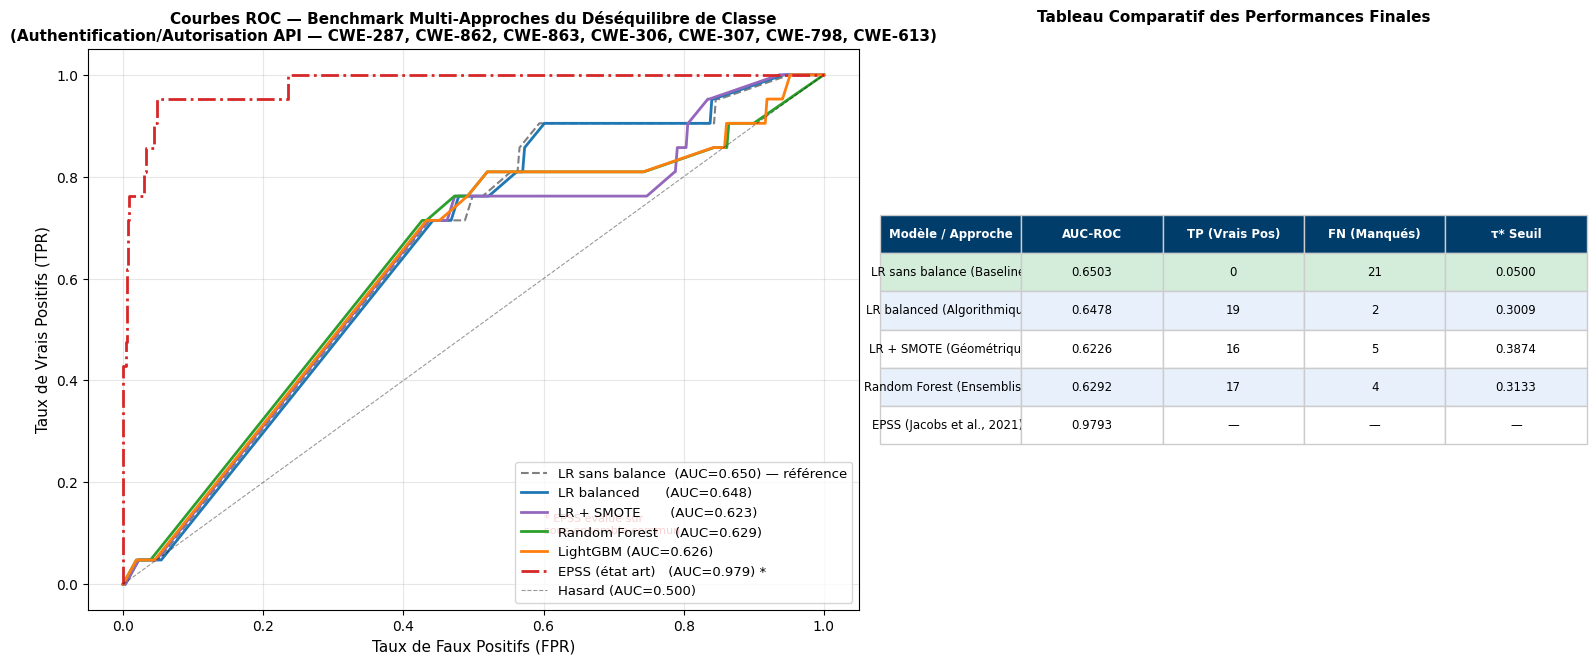

[+] Figure sauvegardée : data/comparaison_complete_modeles.pdf


In [8]:
fig = plt.figure(figsize=(16, 7))
gs  = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.2, 1])

# ── Panel gauche : Courbes ROC ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

ax1.plot(fpr_base,  tpr_base,  lw=1.5, ls='--', color='gray',
         label=f'LR sans balance  (AUC={auc_base:.3f}) — référence')
ax1.plot(fpr_bal,   tpr_bal,   lw=2,   color='#1f77b4',
         label=f'LR balanced      (AUC={auc_bal:.3f})')
ax1.plot(fpr_smote, tpr_smote, lw=2,   color='#9467bd',
         label=f'LR + SMOTE       (AUC={auc_smote:.3f})')
ax1.plot(fpr_rf,    tpr_rf,    lw=2,   color='#2ca02c',
         label=f'Random Forest    (AUC={auc_rf:.3f})')
ax1.plot(fpr_lgb, tpr_lgb, lw=2, color='#ff7f0e', ls='-',
          label=f'LightGBM (AUC={auc_lgb:.3f})')
if epss_available:
    ax1.plot(fpr_ep, tpr_ep, lw=2, ls='-.', color='#d62728',
             label=f'EPSS (état art)   (AUC={auc_ep:.3f}) *')
ax1.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.4, label='Hasard (AUC=0.500)')

ax1.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
ax1.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
ax1.set_title(
    'Courbes ROC — Benchmark Multi-Approches du Déséquilibre de Classe\n'
    '(Authentification/Autorisation API — CWE-287, CWE-862, CWE-863, CWE-306, CWE-307, CWE-798, CWE-613)',
    fontsize=11, fontweight='bold'
)
ax1.legend(loc='lower right', fontsize=9.5)
ax1.grid(alpha=0.3)
if epss_available:
    ax1.annotate('* EPSS évalué sur\nsous-ensemble commun',
                 xy=(0.6, 0.1), fontsize=8, color='#d62728')

# ── Panel droit : Tableau récapitulatif ────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.axis('off')

col_labels = ['Modèle / Approche', 'AUC-ROC', 'TP (Vrais Pos)', 'FN (Manqués)', 'τ* Seuil']
rows = [
    ['LR sans balance (Baseline)',      f'{auc_base:.4f}',  str(cm_base[1,1]),  str(cm_base[1,0]),  '0.0500'],
    ['LR balanced (Algorithmique)',     f'{auc_bal:.4f}',   str(cm_bal[1,1]),   str(cm_bal[1,0]),   f'{tau_bal:.4f}'],
    ['LR + SMOTE (Géométrique)',        f'{auc_smote:.4f}', str(cm_smote[1,1]), str(cm_smote[1,0]), f'{tau_smote:.4f}'],
    ['Random Forest (Ensembliste)',     f'{auc_rf:.4f}',    str(cm_rf[1,1]),    str(cm_rf[1,0]),    f'{tau_rf:.4f}'],
]
if epss_available:
    rows.append(['EPSS (Jacobs et al., 2021)*', f'{auc_ep:.4f}', '—', '—', '—'])

table = ax2.table(cellText=rows, colLabels=col_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1.1, 2.2)

header_color = '#003d6b'
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#e8f0fb')
    cell.set_edgecolor('#cccccc')

all_aucs   = [auc_base, auc_bal, auc_smote, auc_rf]
best_index = all_aucs.index(max(all_aucs)) + 1
for col in range(len(col_labels)):
    table[best_index, col].set_facecolor('#d4edda')

ax2.set_title('Tableau Comparatif des Performances Finales',
              fontsize=11, fontweight='bold', pad=20)

plt.tight_layout(pad=2.0)
plt.savefig('data/comparaison_complete_modeles.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('[+] Figure sauvegardée : data/comparaison_complete_modeles.pdf')

## Résumé chiffré — Valeurs à reporter dans le Chapitre 4

Ce bloc affiche toutes les valeurs numériques finales à insérer directement dans les tableaux du mémoire.

In [9]:
print('=' * 65)
print('VALEURS FINALES À REPORTER DANS LE MÉMOIRE')
print('=' * 65)
print()
print('DATASET')
print(f'  N total              : {len(df):,}')
print(f'  N train              : {len(X_train):,}')
print(f'  N test               : {len(X_test):,}')
print(f'  Ratio Y=1            : {np.mean(Y):.4f} ({int(np.sum(Y))} exploitées)')
print()
print('PERFORMANCES SUR L ENSEMBLE DE TEST COMPLET')
print(f'  LR sans balance      : AUC = {auc_base:.4f}')
print(f'  LR balanced          : AUC = {auc_bal:.4f}')
print(f'  LR + SMOTE           : AUC = {auc_smote:.4f}')
print(f'  Random Forest        : AUC = {auc_rf:.4f}')
print()
print('SEUILS DE YOUDEN')
print(f'  LR balanced  τ*      : {tau_bal:.6f}')
print(f'  LR + SMOTE   τ*      : {tau_smote:.6f}')
print(f'  Random Forest τ*     : {tau_rf:.6f}')
print()
print('MATRICE DE CONFUSION — MEILLEUR MODÈLE')
_models = [('LR balanced', auc_bal, cm_bal), ('LR + SMOTE', auc_smote, cm_smote), ('Random Forest', auc_rf, cm_rf)]
best_model, _, best_cm = max(_models, key=lambda x: x[1])
print(f'  Meilleur modèle : {best_model} (AUC={max(auc_bal, auc_smote, auc_rf):.4f})')
print(f'  TN={best_cm[0,0]:4d}  FP={best_cm[0,1]:4d}')
print(f'  FN={best_cm[1,0]:4d}  TP={best_cm[1,1]:4d}')
if epss_available:
    print()
    print('COMPARAISON EPSS (sous-ensemble commun)')
    print(f'  N sous-ensemble      : {n_match}')
    print(f'  AUC LR balanced      : {auc_lr2:.4f}')
    print(f'  AUC Random Forest    : {auc_rf2:.4f}')
    print(f'  AUC EPSS             : {auc_ep:.4f}')
print()
print('FIGURES GÉNÉRÉES')
print('  data/importance_variables_rf.pdf')
print('  data/comparaison_complete_modeles.pdf')

print()
print('JOURNAL DES EXPÉRIENCES (toutes itérations, NB1 + NB2)')
print(f'  {EXPERIMENTS_LOG_FILE}')
print('  -> pd.read_csv(EXPERIMENTS_LOG_FILE) pour comparer AUC / seuils / paramètres entre runs')

VALEURS FINALES À REPORTER DANS LE MÉMOIRE

DATASET
  N total              : 9,995
  N train              : 7,496
  N test               : 2,499
  Ratio Y=1            : 0.0084 (84 exploitées)

PERFORMANCES SUR L ENSEMBLE DE TEST COMPLET
  LR sans balance      : AUC = 0.6503
  LR balanced          : AUC = 0.6478
  LR + SMOTE           : AUC = 0.6226
  Random Forest        : AUC = 0.6292

SEUILS DE YOUDEN
  LR balanced  τ*      : 0.300893
  LR + SMOTE   τ*      : 0.387412
  Random Forest τ*     : 0.313260

MATRICE DE CONFUSION — MEILLEUR MODÈLE
  Meilleur modèle : LR balanced (AUC=0.6478)
  TN= 988  FP=1490
  FN=   2  TP=  19

COMPARAISON EPSS (sous-ensemble commun)
  N sous-ensemble      : 2499
  AUC LR balanced      : 0.6478
  AUC Random Forest    : 0.6292
  AUC EPSS             : 0.9793

FIGURES GÉNÉRÉES
  data/importance_variables_rf.pdf
  data/comparaison_complete_modeles.pdf

JOURNAL DES EXPÉRIENCES (toutes itérations, NB1 + NB2)
  data\experiments_log.csv
  -> pd.read_csv(EXPERIM